In [7]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [8]:
def half_normal(x, sd):
    """Half-normal detection function."""
    return np.exp(-x**2 / (2 * sd**2))


def make_array(geometry='square', spacing=5.0, offset=4.0):
    """Return x, y coordinates for a given array geometry."""
    if geometry == 'square':
        xs = np.array([-1.5, -0.5, 0.5, 1.5, -1.5, -0.5, 0.5, 1.5]) * spacing
        ys = np.array([0, 0, 0, 0, 1, 1, 1, 1]) * spacing + offset
    elif geometry == 'triangular':
        xs = np.array([-spacing, 0, spacing, -spacing/2, spacing/2, -spacing, 0, spacing])
        ys = np.array([0, 0, 0, np.sqrt(3)/2*spacing, np.sqrt(3)/2*spacing,
                       np.sqrt(3)*spacing, np.sqrt(3)*spacing, np.sqrt(3)*spacing]) + offset
    elif geometry == 'line':
        xs = np.linspace(-3.5, 3.5, 8) * spacing
        ys = np.ones(8) * offset
    else:
        raise ValueError("Unsupported geometry type.")
    return xs, ys

# ---------- Distance and probability computations ----------
def compute_distances(xs, ys, grid_x, grid_y):
    """Compute distances from each hydrophone to each grid point."""
    gx, gy = np.meshgrid(grid_x, grid_y, indexing='ij')
    return np.sqrt((gx[None, :, :] - xs[:, None, None])**2 +
                   (gy[None, :, :] - ys[:, None, None])**2)

def calculate_probs(det_func, distances):
    """Calculate detection probabilities for each unit."""
    return det_func(distances)

# ---------- Combine detection probabilities ----------
def detection_probabilities(probs):
    """Compute joint detection probabilities across units."""
    num_units, nx, ny = probs.shape
    no_det = np.prod(1 - probs, axis=0)
    one_det = np.zeros((nx, ny))
    two_det = np.zeros((nx, ny))
    three_det = np.zeros((nx, ny))

    for i in range(num_units):
        one_det += probs[i] * np.prod(1 - np.delete(probs, i, 0), axis=0)

    for i in range(num_units):
        for j in range(i+1, num_units):
            two_det += probs[i] * probs[j] * np.prod(1 - np.delete(probs, [i, j], 0), axis=0)

    for i in range(num_units):
        for j in range(i+1, num_units):
            for k in range(j+1, num_units):
                three_det += probs[i] * probs[j] * probs[k] * np.prod(1 - np.delete(probs, [i, j, k], 0), axis=0)

    three_plus = 1 - no_det - one_det - two_det
    four_plus = 1 - no_det - one_det - two_det - three_det

    return four_plus

# ---------- Semi-circle mask and mean/min calculation ----------
def semicircle_mask(grid_x, grid_y, radius, center=(0, 0), upper_half=True):
    """Return a boolean mask for points inside a semi-circle."""
    gx, gy = np.meshgrid(grid_x, grid_y, indexing='ij')
    dist = np.sqrt((gx - center[0])**2 + (gy - center[1])**2)
    mask = dist <= radius
    if upper_half:
        mask &= gy >= center[1]  # upper half
    return mask

def mean_probability_in_semicircle(prob_map, grid_x, grid_y, radius, center=(0, 0)):
    """Compute mean probability inside the semi-circle."""
    mask = semicircle_mask(grid_x, grid_y, radius, center)
    return np.nanmean(prob_map[mask])

def min_probability_in_semicircle(prob_map, grid_x, grid_y, radius, center=(0, 0)):
    """Compute minimum probability inside the semi-circle."""
    mask = semicircle_mask(grid_x, grid_y, radius, center)
    return np.nanmin(prob_map[mask])

# ---------- Visualization ----------
def plot_probability_map(grid_x, grid_y, prob_map, array_xs, array_ys, radius, title="Detection Probability (4+ Units)"):
    plt.figure(figsize=(8, 6))
    plt.pcolormesh(grid_x, grid_y, prob_map.T, cmap='magma', shading='auto', vmin=0, vmax=1)
    plt.colorbar(label="Probability")
    plt.scatter(array_xs, array_ys, c='white', edgecolor='k', s=60, label="Hydrophones")

    # Draw semi-circle
    theta = np.linspace(0, np.pi, 200)
    x_circle = radius * np.cos(theta)
    y_circle = radius * np.sin(theta)
    plt.plot(x_circle, y_circle, 'c--', lw=2, label=f"Semi-circle (r={radius} km)")

    plt.xlabel("X (km)")
    plt.ylabel("Y (km)")
    plt.title(title)
    plt.legend()
    plt.gca().set_aspect('equal', 'box')
    plt.tight_layout()
    plt.show()

In [9]:

# ---------- GA Parameters ----------
POP_SIZE = 100           # number of candidate arrays per generation
N_GENERATIONS = 150       # number of generations
NUM_RECORDERS = 8        # number of recorders in each array
BOUNDS = (-30, 30, -30, 30)  # (xmin, xmax, ymin, ymax)
MUTATION_RATE = 0.3
MUTATION_STD = 1.5       # km
RADIUS = 20.0
EMPTY_PENALTY = True
CLOSE_PENALTY = True

# ---------- Helper: generate a random array ----------
def random_array(num_recorders=NUM_RECORDERS, bounds=BOUNDS):
    xmin, xmax, ymin, ymax = bounds
    xs = np.random.uniform(xmin, xmax, num_recorders)
    ys = np.random.uniform(ymin, ymax, num_recorders)
    return xs, ys

# ---------- Fitness function ----------
def fitness(xs, ys, grid_x, grid_y, det_func):
    """Compute mean detection probability in region for given recorder layout."""
    distances = compute_distances(xs, ys, grid_x, grid_y)
    probs = calculate_probs(det_func, distances)
    prob_map = detection_probabilities(probs)
    score = mean_probability_in_semicircle(prob_map, grid_x, grid_y, RADIUS)
    if EMPTY_PENALTY:
      # ---- Penalty for empty/low-detection regions ----
      mask = semicircle_mask(grid_x, grid_y, RADIUS)
      low_prob_area = np.mean(prob_map[mask] < 0.2)  # fraction of points with very low prob (<0.2)
      penalty_weight = 0.3  # tune this (0.1–0.5 works well)

      # Apply penalty
      score -= penalty_weight * low_prob_area
    if CLOSE_PENALTY:
      min_dist_allowed = 3.0  # km, you can tune this
      penalty_strength = 0.2  # how much it hurts the fitness if recorders are close

      # Compute all pairwise distances
      dists = np.sqrt((xs[:, None] - xs[None, :])**2 + (ys[:, None] - ys[None, :])**2)
      np.fill_diagonal(dists, np.inf)  # ignore self-distances

      too_close_fraction = np.mean(dists < min_dist_allowed)
      score -= penalty_strength * too_close_fraction
    return score

# ---------- Selection ----------
def select_parents(population, fitnesses, num_parents):
    idx = np.argsort(fitnesses)[-num_parents:]
    return [population[i] for i in idx]

# ---------- Crossover ----------
def crossover(parent1, parent2):
    """Simple arithmetic crossover."""
    alpha = np.random.rand()
    child_xs = alpha * parent1[0] + (1 - alpha) * parent2[0]
    child_ys = alpha * parent1[1] + (1 - alpha) * parent2[1]
    return child_xs, child_ys

# ---------- Mutation ----------
def mutate(xs, ys, rate=MUTATION_RATE, std=MUTATION_STD, bounds=BOUNDS):
    xs_new, ys_new = xs.copy(), ys.copy()
    mask = np.random.rand(len(xs)) < rate
    xs_new[mask] += np.random.normal(0, std, np.sum(mask))
    ys_new[mask] += np.random.normal(0, std, np.sum(mask))
    # enforce bounds
    xs_new = np.clip(xs_new, bounds[0], bounds[1])
    ys_new = np.clip(ys_new, bounds[2], bounds[3])
    return xs_new, ys_new

# ---------- Genetic Algorithm ----------
def genetic_optimize(grid_x, grid_y, det_func):
    population = [random_array() for _ in range(POP_SIZE)]

    best_scores = []
    for gen in range(N_GENERATIONS):
        fitnesses = [fitness(xs, ys, grid_x, grid_y, det_func) for xs, ys in population]
        # print(fitnesses)

        best_idx = np.argmax(fitnesses)
        mean_fit = np.mean(fitnesses)
        best_fit = fitnesses[best_idx]
        best_scores.append(best_fit)

        print(f"Gen {gen+1:02d} | Mean fitness = {mean_fit:.4f} | Best = {best_fit:.4f}")

        # Selection
        parents = select_parents(population, fitnesses, num_parents=5)
        # print(parents)
        # Reproduction
        new_population = [population[best_idx]]  # elitism
        while len(new_population) < POP_SIZE:
            p1, p2 = random.sample(parents, 2)
            child = crossover(p1, p2)
            child = mutate(*child)
            new_population.append(child)

        population = new_population

    best_idx = np.argmax([fitness(xs, ys, grid_x, grid_y, det_func) for xs, ys in population])
    best_individual = population[best_idx]
    return best_individual, best_scores


Gen 01 | Mean fitness = -0.2673 | Best = 0.1165
Gen 02 | Mean fitness = 0.1082 | Best = 0.3779
Gen 03 | Mean fitness = 0.3900 | Best = 0.4928
Gen 04 | Mean fitness = 0.4720 | Best = 0.5131
Gen 05 | Mean fitness = 0.5035 | Best = 0.5350
Gen 06 | Mean fitness = 0.5279 | Best = 0.5581
Gen 07 | Mean fitness = 0.5546 | Best = 0.5884
Gen 08 | Mean fitness = 0.5720 | Best = 0.5931
Gen 09 | Mean fitness = 0.5880 | Best = 0.6040
Gen 10 | Mean fitness = 0.5976 | Best = 0.6136
Gen 11 | Mean fitness = 0.6055 | Best = 0.6181
Gen 12 | Mean fitness = 0.6129 | Best = 0.6270
Gen 13 | Mean fitness = 0.6169 | Best = 0.6293
Gen 14 | Mean fitness = 0.6195 | Best = 0.6313
Gen 15 | Mean fitness = 0.6220 | Best = 0.6344
Gen 16 | Mean fitness = 0.6230 | Best = 0.6344
Gen 17 | Mean fitness = 0.6238 | Best = 0.6354
Gen 18 | Mean fitness = 0.6243 | Best = 0.6354
Gen 19 | Mean fitness = 0.6242 | Best = 0.6359
Gen 20 | Mean fitness = 0.6242 | Best = 0.6360
Gen 21 | Mean fitness = 0.6246 | Best = 0.6362
Gen 22 | Mea

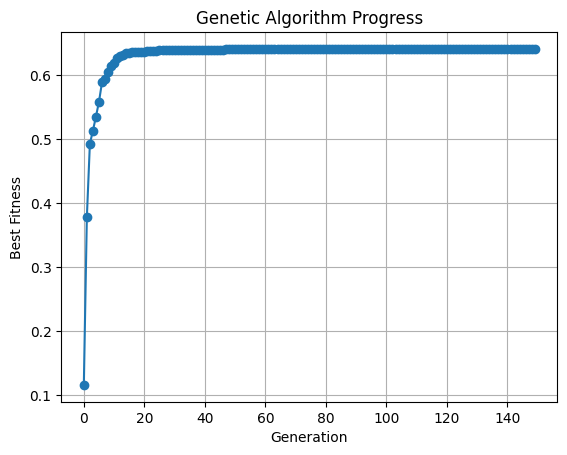

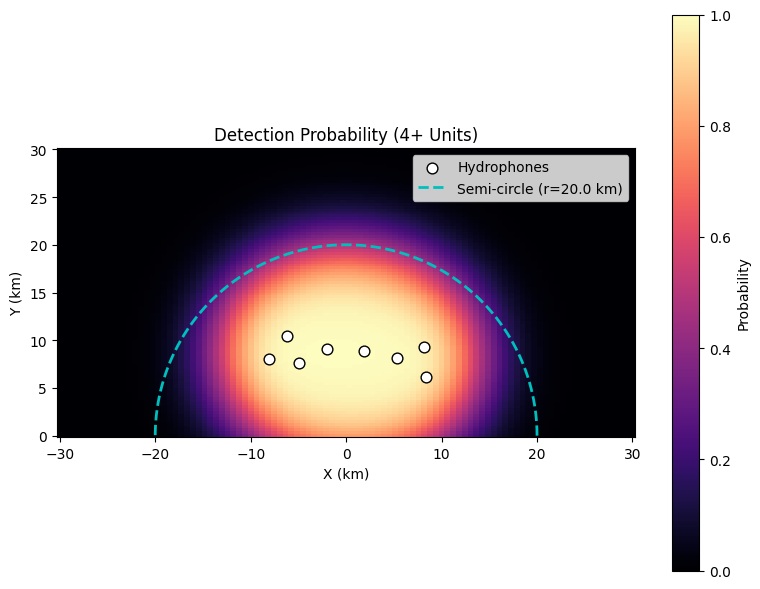

In [10]:
if __name__ == "__main__":

    # Grid definition
    xlim, ylim = (-30, 30), (0, 30)
    grid_x = np.linspace(*xlim, 100)
    grid_y = np.linspace(*ylim, 100)

    # Detection function
    sd = 10.0
    det_func = lambda d: half_normal(d, sd)

    best_individual, scores = genetic_optimize(grid_x, grid_y, det_func)

    xs_best, ys_best = best_individual
    print("\nBest layout coordinates:")
    for i in range(len(xs_best)):
        print(f"Recorder {i+1}: ({xs_best[i]:.2f}, {ys_best[i]:.2f})")

    # Plot fitness over generations
    plt.figure()
    plt.plot(scores, marker='o')
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.title("Genetic Algorithm Progress")
    plt.grid(True)
    plt.show()

    # Plot final probability map
    distances = compute_distances(xs_best, ys_best, grid_x, grid_y)
    probs = calculate_probs(det_func, distances)
    prob_map = detection_probabilities(probs)
    plot_probability_map(grid_x, grid_y, prob_map, xs_best, ys_best, RADIUS)
